**IMPORTING DRIVE**



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**INSTALING PACKAGES**



In [2]:
!pip install --upgrade pip

!pip install numpy>=1.24 matplotlib>=3.7

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 82.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [3]:
!pip install numpy>=1.24 matplotlib>=3.7 seaborn pandas

In [4]:
!pip install torch torchvision torchaudio numpy matplotlib scipy scikit-learn fastapi uvicorn pydantic tqdm -q
print("All packages installed!")

All packages installed!


**CREATING FOLDERS**

In [5]:
import os

folders = ['data', 'models', 'src', 'api', 'notebooks']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created:", folders)

Folders created: ['data', 'models', 'src', 'api', 'notebooks']


**CREATING CHANNEL**

In [6]:
%%writefile src/channel.py
import numpy as np

class Channel6G:
    def __init__(self, n_subcarriers=64, n_paths=6, seed=42):
        self.n_subcarriers = n_subcarriers
        self.n_paths = n_paths
        np.random.seed(seed)

    def generate_rayleigh_channel(self, batch_size):
        h_real = np.random.randn(batch_size, self.n_subcarriers)
        h_imag = np.random.randn(batch_size, self.n_subcarriers)
        H = (h_real + 1j * h_imag) / np.sqrt(2)
        return H

    def add_awgn(self, signal, snr_db):
        snr_linear = 10 ** (snr_db / 10.0)
        signal_power = np.mean(np.abs(signal) ** 2)
        noise_power = signal_power / snr_linear
        noise = np.sqrt(noise_power / 2) * (
            np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape)
        )
        return signal + noise

    def transmit(self, x, snr_db):
        batch_size = x.shape[0]
        H = self.generate_rayleigh_channel(batch_size)
        y = H * x
        y_noisy = self.add_awgn(y, snr_db)
        return y_noisy, H, x

    def qpsk_modulate(self, bits):
        bits = bits.reshape(-1, 2)
        real = 2 * bits[:, 0] - 1
        imag = 2 * bits[:, 1] - 1
        return (real + 1j * imag) / np.sqrt(2)

    def qpsk_demodulate(self, symbols):
        bits_real = (np.real(symbols) > 0).astype(int)
        bits_imag = (np.imag(symbols) > 0).astype(int)
        return np.stack([bits_real, bits_imag], axis=-1).reshape(-1)

print("channel.py created!")

Writing src/channel.py


**CREATING DATASET**

In [7]:
%%writefile src/dataset.py
import sys
sys.path.insert(0, 'src')

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from channel import Channel6G

class ChannelDataset(Dataset):
    def __init__(self, n_samples=100000, snr_db=10.0, n_subcarriers=64):
        self.channel = Channel6G(n_subcarriers=n_subcarriers)
        self.n_subcarriers = n_subcarriers
        self.features, self.targets = self._generate(n_samples, snr_db)

    def _generate(self, n_samples, snr_db):
        bits = np.random.randint(0, 2, (n_samples, self.n_subcarriers * 2))
        x = np.array([self.channel.qpsk_modulate(bits[i]) for i in range(n_samples)])
        y, H, _ = self.channel.transmit(x, snr_db)
        feats = np.concatenate([
            np.real(y), np.imag(y), np.real(H), np.imag(H)
        ], axis=1).astype(np.float32)
        targets = np.concatenate([np.real(x), np.imag(x)], axis=1).astype(np.float32)
        return feats, targets

    def __len__(self): return len(self.features)

    def __getitem__(self, idx):
        return torch.tensor(self.features[idx]), torch.tensor(self.targets[idx])

def get_dataloaders(snr_db=10.0, batch_size=512):
    train_ds = ChannelDataset(n_samples=80000, snr_db=snr_db)
    val_ds   = ChannelDataset(n_samples=20000, snr_db=snr_db)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    return train_dl, val_dl

print("dataset.py created!")

Writing src/dataset.py


**CREATING MODEL**

In [8]:
%%writefile src/model.py
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.LayerNorm(dim), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(dim, dim), nn.LayerNorm(dim)
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class NeuralEqualizer(nn.Module):
    def __init__(self, n_subcarriers=64, hidden_dim=512, n_blocks=4):
        super().__init__()
        in_dim  = 4 * n_subcarriers
        out_dim = 2 * n_subcarriers
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU()
        )
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_dim) for _ in range(n_blocks)])
        self.output_proj = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        z = self.input_proj(x)
        z = self.blocks(z)
        return self.output_proj(z)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("model.py created!")

Writing src/model.py


**MINIMUM MEAN SQUARE ERROR (MMSE)**

In [9]:
%%writefile src/mmse.py
import numpy as np

def mmse_equalize(y, H, snr_db):
    snr_linear = 10 ** (snr_db / 10.0)
    H_conj  = np.conj(H)
    H_mag2  = np.abs(H) ** 2
    w       = H_conj / (H_mag2 + 1.0 / snr_linear)
    return w * y

def compute_ber(x_original, x_estimated, channel):
    bits_tx = channel.qpsk_demodulate(x_original.flatten())
    bits_rx = channel.qpsk_demodulate(x_estimated.flatten())
    return np.mean(bits_tx != bits_rx)

print("mmse.py created!")

Writing src/mmse.py


**TRAINING THE MODEL**

In [10]:
%%writefile src/train.py
import sys
sys.path.insert(0, 'src')

import torch, torch.nn as nn, torch.optim as optim, os, json
from torch.optim.lr_scheduler import CosineAnnealingLR
from model import NeuralEqualizer, count_parameters
from dataset import get_dataloaders

DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_SUBCARRIERS  = 64
HIDDEN_DIM     = 512
N_BLOCKS       = 4
EPOCHS         = 50
LR             = 1e-3
SNR_TRAIN_DB   = 10.0

def train():
    print(f"Training on {DEVICE}")
    model = NeuralEqualizer(N_SUBCARRIERS, HIDDEN_DIM, N_BLOCKS).to(DEVICE)
    print(f"Parameters: {count_parameters(model):,}")

    train_dl, val_dl = get_dataloaders(SNR_TRAIN_DB, batch_size=512)
    criterion  = nn.MSELoss()
    optimizer  = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler  = CosineAnnealingLR(optimizer, T_max=EPOCHS)
    history    = {'train_loss': [], 'val_loss': []}
    best_val   = float('inf')

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for X, y in train_dl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        scheduler.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y in val_dl:
                X, y = X.to(DEVICE), y.to(DEVICE)
                val_loss += criterion(model(X), y).item()

        tl = train_loss / len(train_dl)
        vl = val_loss   / len(val_dl)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)

        if vl < best_val:
            best_val = vl
            os.makedirs('models', exist_ok=True)
            torch.save(model.state_dict(), 'models/best_model.pth')

        if epoch % 5 == 0:
            print(f"Epoch {epoch:>3}/{EPOCHS}  Train: {tl:.5f}  Val: {vl:.5f}")

    with open('models/history.json', 'w') as f:
        json.dump(history, f)
    print(f"\nTraining complete. Best val loss: {best_val:.5f}")
    print("Model saved → models/best_model.pth")

if __name__ == '__main__':
    train()

print("train.py created!")

Writing src/train.py


In [11]:
%%writefile src/evaluate.py
import sys
sys.path.insert(0, 'src')

import numpy as np, torch, matplotlib.pyplot as plt
from model import NeuralEqualizer
from channel import Channel6G
from mmse import mmse_equalize, compute_ber

DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_SUBCARRIERS   = 64
N_TEST_SAMPLES  = 10000
SNR_RANGE_DB    = np.arange(-5, 26, 2.5)

def evaluate_neural(model, channel, snr_db):
    from dataset import ChannelDataset
    ds  = ChannelDataset(N_TEST_SAMPLES, snr_db, N_SUBCARRIERS)
    X_t = torch.tensor(ds.features).to(DEVICE)
    with torch.no_grad():
        pred = model(X_t).cpu().numpy()
    x_hat  = pred[:, :N_SUBCARRIERS] + 1j * pred[:, N_SUBCARRIERS:]
    x_orig = ds.targets[:, :N_SUBCARRIERS] + 1j * ds.targets[:, N_SUBCARRIERS:]
    return compute_ber(x_orig, x_hat, channel)

def evaluate_mmse(channel, snr_db):
    bits  = np.random.randint(0, 2, (N_TEST_SAMPLES, N_SUBCARRIERS * 2))
    x     = np.array([channel.qpsk_modulate(bits[i]) for i in range(N_TEST_SAMPLES)])
    y, H, _ = channel.transmit(x, snr_db)
    x_hat = mmse_equalize(y, H, snr_db)
    return compute_ber(x, x_hat, channel)

def run_benchmark():
    channel = Channel6G(N_SUBCARRIERS)
    model   = NeuralEqualizer(N_SUBCARRIERS).to(DEVICE)
    model.load_state_dict(torch.load('models/best_model.pth', map_location=DEVICE))
    model.eval()

    ber_nn, ber_mmse = [], []
    for snr in SNR_RANGE_DB:
        ber_nn.append(evaluate_neural(model, channel, snr))
        ber_mmse.append(evaluate_mmse(channel, snr))
        print(f"SNR {snr:>5.1f} dB | NN BER: {ber_nn[-1]:.4f} | MMSE BER: {ber_mmse[-1]:.4f}")

    plt.figure(figsize=(9, 5))
    plt.semilogy(SNR_RANGE_DB, ber_mmse, 'b--o', label='MMSE (baseline)', linewidth=2)
    plt.semilogy(SNR_RANGE_DB, ber_nn,   'r-s',  label='Neural Equalizer', linewidth=2)
    plt.xlabel('SNR (dB)', fontsize=13)
    plt.ylabel('Bit Error Rate (BER)', fontsize=13)
    plt.title('Neural Equalizer vs MMSE | 6G OFDM Rayleigh Channel', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('ber_comparison.png', dpi=150)
    plt.show()
    print("Plot saved → ber_comparison.png")

if __name__ == '__main__':
    run_benchmark()

print("evaluate.py created!")

Writing src/evaluate.py


In [12]:
import sys
sys.path.insert(0, 'src')


%run src/train.py

model.py created!
channel.py created!
dataset.py created!
Training on cuda
Parameters: 2,307,712
Epoch   5/50  Train: 0.47281  Val: 0.47709
Epoch  10/50  Train: 0.28927  Val: 0.27847
Epoch  15/50  Train: 0.21506  Val: 0.21505
Epoch  20/50  Train: 0.18338  Val: 0.18961
Epoch  25/50  Train: 0.16593  Val: 0.17715
Epoch  30/50  Train: 0.15490  Val: 0.17097
Epoch  35/50  Train: 0.14717  Val: 0.16747
Epoch  40/50  Train: 0.14171  Val: 0.16471
Epoch  45/50  Train: 0.13847  Val: 0.16370
Epoch  50/50  Train: 0.13716  Val: 0.16351

✅ Training complete. Best val loss: 0.16351
Model saved → models/best_model.pth
train.py created!


mmse.py created!
SNR  -5.0 dB | NN BER: 0.3642 | MMSE BER: 0.3151
SNR  -2.5 dB | NN BER: 0.3157 | MMSE BER: 0.2656
SNR   0.0 dB | NN BER: 0.2623 | MMSE BER: 0.2112
SNR   2.5 dB | NN BER: 0.2084 | MMSE BER: 0.1568
SNR   5.0 dB | NN BER: 0.1596 | MMSE BER: 0.1083
SNR   7.5 dB | NN BER: 0.1201 | MMSE BER: 0.0704
SNR  10.0 dB | NN BER: 0.0909 | MMSE BER: 0.0435
SNR  12.5 dB | NN BER: 0.0713 | MMSE BER: 0.0258
SNR  15.0 dB | NN BER: 0.0595 | MMSE BER: 0.0149
SNR  17.5 dB | NN BER: 0.0524 | MMSE BER: 0.0086
SNR  20.0 dB | NN BER: 0.0485 | MMSE BER: 0.0049
SNR  22.5 dB | NN BER: 0.0463 | MMSE BER: 0.0027
SNR  25.0 dB | NN BER: 0.0451 | MMSE BER: 0.0015


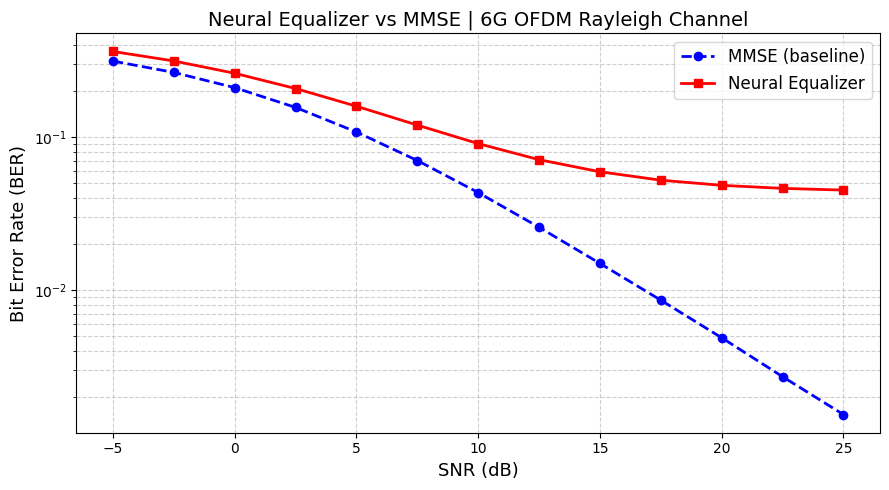

✅ Plot saved → ber_comparison.png
evaluate.py created!


<Figure size 640x480 with 0 Axes>

In [13]:
import sys
sys.path.insert(0, 'src')


%run src/evaluate.py

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
save_dir = '/content/drive/MyDrive/NeuralEqualizer6G/'
os.makedirs(save_dir, exist_ok=True)
shutil.copy('models/best_model.pth', save_dir)
shutil.copy('ber_comparison.png',    save_dir)

print("Model and plot saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model and plot saved to Google Drive!


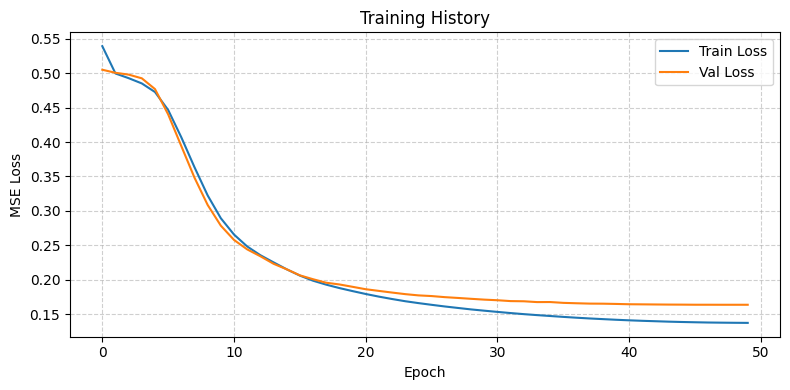

In [15]:
import json, matplotlib.pyplot as plt

with open('models/history.json') as f:
    history = json.load(f)

plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
